<a href="https://colab.research.google.com/github/MateusRsousa/Classificacao_arritmias_ECG/blob/main/Trabalho1_MateusSousa_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1, Aluno: Mateus Ribeiro de Sousa (19205642)



# 1- Carregamento dos dados e EDA inicial

In [ ]:
#inclusão das bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor





In [ ]:
df = pd.read_csv('cars.csv')
df



,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,301
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,True,False,False,True,True,False,False,True,True,317
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,369
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,True,490


##  Análise do Datafrane
Aqui foi feito uma analise do dataframe, observamos que ele possui 38531 linhas e 30 colunas, e possui diversas features, tanto numéricas quanto booleanas e categóricas

In [ ]:
missing_values = df.isnull().sum()
missing_values
## engine_capacity tem 10 dados faltantes

manufacturer_name     0
model_name            0
transmission          0
color                 0
odometer_value        0
year_produced         0
engine_fuel           0
engine_has_gas        0
engine_type           0
engine_capacity      10
body_type             0
has_warranty          0
state                 0
drivetrain            0
price_usd             0
is_exchangeable       0
location_region       0
number_of_photos      0
up_counter            0
feature_0             0
feature_1             0
feature_2             0
feature_3             0
feature_4             0
feature_5             0
feature_6             0
feature_7             0
feature_8             0
feature_9             0
duration_listed       0
dtype: int64

In [ ]:
duplicated_rows = df[df.duplicated(keep=False)]
duplicated_rows


#temos 40 linhas de dados duplicadas

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
5766,Mitsubishi,Lancer,automatic,black,250000,2003,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,False,50
5767,Mitsubishi,Lancer,automatic,black,250000,2003,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,False,50
6555,Citroen,Xantia,mechanical,silver,520000,1998,diesel,False,diesel,2.1,...,True,False,False,False,False,False,False,False,False,16
6556,Citroen,Xantia,mechanical,silver,520000,1998,diesel,False,diesel,2.1,...,True,False,False,False,False,False,False,False,False,16
9995,Ford,Scorpio,mechanical,yellow,55555,1995,gasoline,False,gasoline,2.0,...,False,False,False,False,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32318,Skoda,Rapid,mechanical,brown,0,2019,gasoline,False,gasoline,1.6,...,False,False,False,False,False,False,False,False,False,2
32320,Skoda,Rapid,mechanical,silver,0,2019,gasoline,False,gasoline,1.6,...,False,False,False,False,False,False,False,False,False,2
32321,Skoda,Rapid,mechanical,silver,0,2019,gasoline,False,gasoline,1.6,...,False,False,False,False,False,False,False,False,False,2
32324,Skoda,Rapid,mechanical,white,0,2019,gasoline,False,gasoline,1.6,...,False,False,False,False,False,False,False,False,False,2


In [ ]:
# Conta todas as ocorrências de linhas
duplicadas = df.value_counts()

# Para cada linha duplicada (com mais de 1 ocorrência), contamos quantas precisam ser excluídas
linhas_a_excluir = (duplicadas[duplicadas > 1] - 1).sum()

print(f"Quantidade de linhas que devem ser excluídas: {linhas_a_excluir}")


Quantidade de linhas que devem ser excluídas: 40


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  object 
 1   model_name         38531 non-null  object 
 2   transmission       38531 non-null  object 
 3   color              38531 non-null  object 
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  object 
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  object 
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  object 
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  object 
 13  drivetrain         38531 non-null  object 
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    385

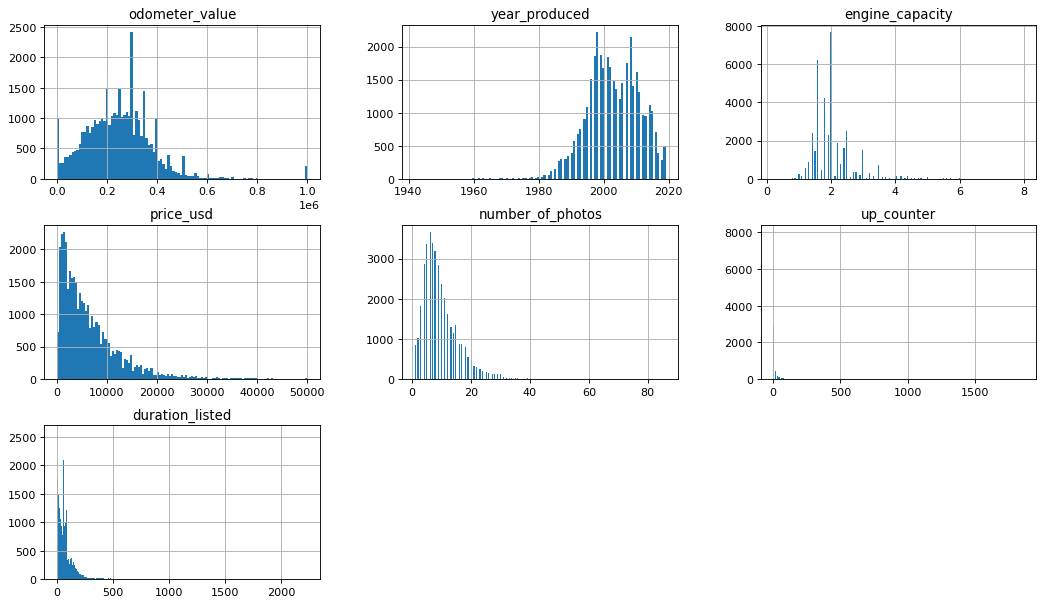

In [ ]:
df.hist(bins='auto', figsize=(16,9), layout=(3,3));

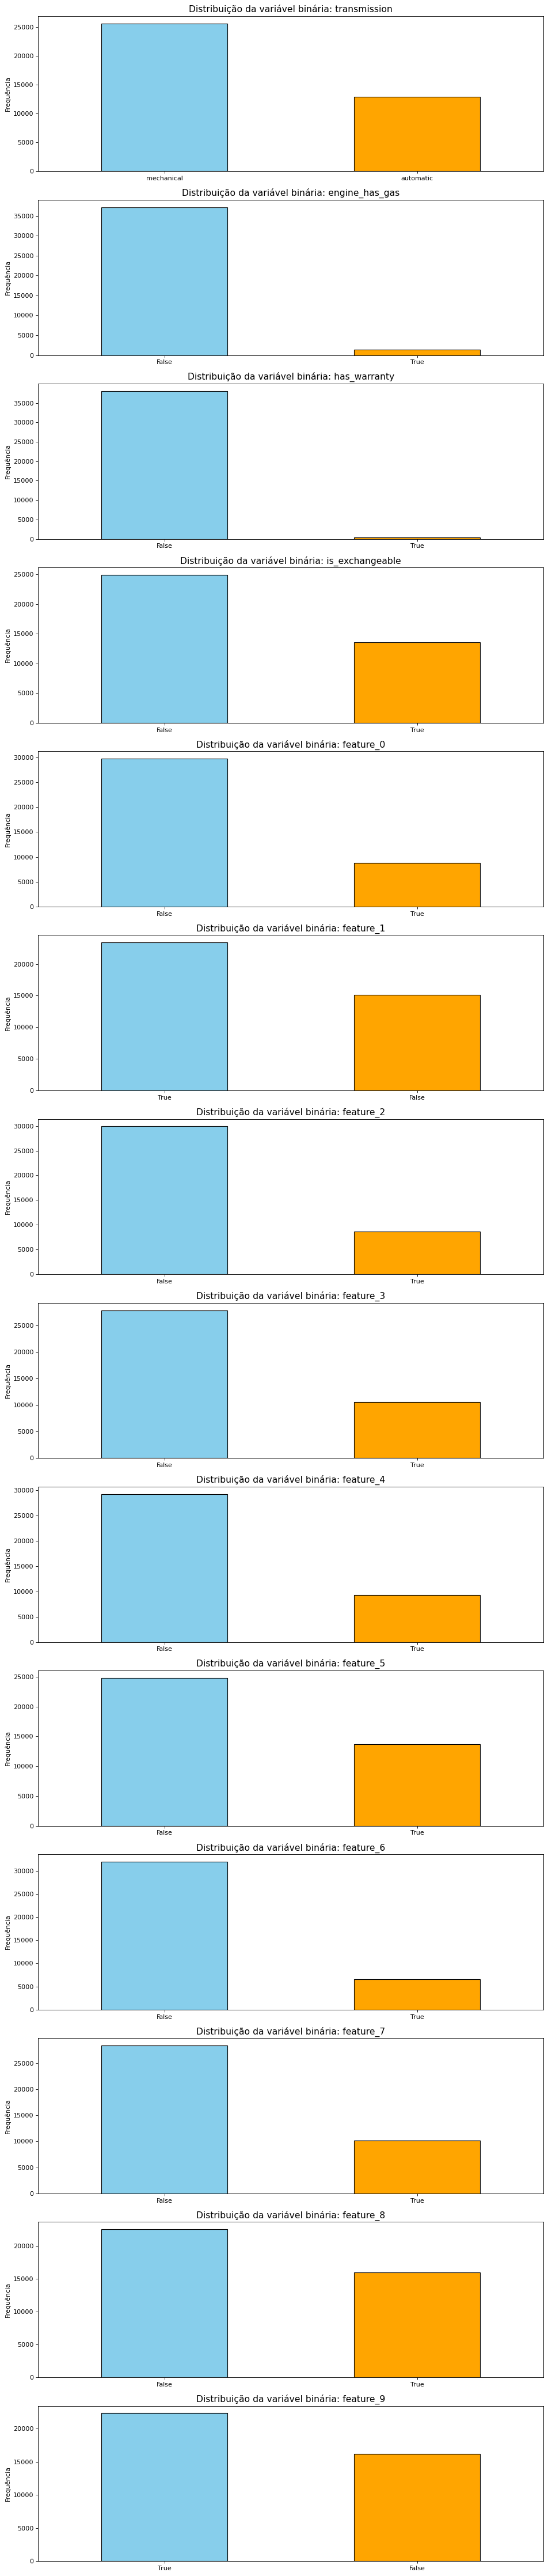

In [ ]:
colunas_binarias = [col for col in df.columns if df[col].nunique() == 2]

# Plotar a distribuição de cada variável binária
plt.figure(figsize=(12, len(colunas_binarias) * 4))

for i, col in enumerate(colunas_binarias, 1):
    plt.subplot(len(colunas_binarias), 1, i)
    df[col].value_counts().plot(kind='bar', color=['skyblue', 'orange'], edgecolor='black')
    plt.title(f'Distribuição da variável binária: {col}', fontsize=14)
    plt.ylabel('Frequência')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



## Discussão dos resultados
-Até esta parte verificamos que possuimos 10 linhas com dados faltantes, todos esses dados faltantes são da feature engine_capacity.
-Temos também um total de 40 linhas que precisaram ser excluidas por serem duplicadas.
-Observando os histogramas plotados, podemos observar um possível outlier em odometer_value, que pode ter agrupado no final valores maiores ou iguais a 1.
-Observamos por exemplo carros com valores muito baixo ou até proximos de zero que podem atrapalhar o modelo e também carros que percorreram distâncias muito grandes que podem até ser erro.

# 2-Limpeza e separação dos dados

In [ ]:
df = df.drop_duplicates()
df.shape[0]


# 38531 - 40 linhas duplicadas = 38491 linhas



38491

In [ ]:
df = df[df['state'] == 'owned']

#deixando apenas carros usados


In [ ]:
df = df[df['odometer_value'] < 999999]
#odometro <999999

In [ ]:
df = df[df['price_usd'] >= 100]

#deixando apenas carro com valores maiores ou iguais a 100

In [ ]:
df["is_transmission_automatic"] = df["transmission"].str.lower() == "automatic"
df["is_engine_type_diesel"] = df["engine_type"].str.lower() == "diesel"
df

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,is_transmission_automatic,is_engine_type_diesel
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,False,True,False,True,True,True,16,True,False
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,False,True,True,False,False,False,True,83,True,False
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,False,False,False,False,False,True,True,151,True,False
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,86,False,False
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,True,False,False,False,False,True,7,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,False,True,True,False,False,True,True,301,True,False
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,False,True,True,False,False,True,True,317,False,True
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,False,True,True,False,False,True,True,369,True,False
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,False,False,False,False,False,False,True,490,False,False


In [ ]:
modelos = df["model_name"].value_counts()


# Filtrar os modelos que aparecem pelo menos 15 vezes
df = df[df["model_name"].isin(modelos[modelos >= 15].index)]
modelos = df["model_name"].value_counts()
modelos

#observamos que agora no minimo o modelo dos carros que aparece são 15 vezes

Passat      1404
Astra        745
Golf         697
A6           684
Mondeo       624
            ... 
Granta        15
2410          15
Cooper S      15
Venza         15
Orion         15
Name: model_name, Length: 412, dtype: int64

In [ ]:
df = df.drop(columns=["state", "transmission", "engine_type", "duration_listed", "number_of_photos"])


In [ ]:
df

,manufacturer_name,model_name,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_capacity,body_type,has_warranty,...,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,is_transmission_automatic,is_engine_type_diesel
0,Subaru,Outback,silver,190000,2010,gasoline,False,2.5,universal,False,...,True,True,False,True,False,True,True,True,True,False
1,Subaru,Outback,blue,290000,2002,gasoline,False,3.0,universal,False,...,False,False,True,True,False,False,False,True,True,False
2,Subaru,Forester,red,402000,2001,gasoline,False,2.5,suv,False,...,False,False,False,False,False,False,True,True,True,False
3,Subaru,Impreza,blue,10000,1999,gasoline,False,3.0,sedan,False,...,False,False,False,False,False,False,False,False,False,False
4,Subaru,Legacy,black,280000,2001,gasoline,False,2.5,universal,False,...,False,True,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,silver,290000,2000,gasoline,False,3.5,sedan,False,...,False,False,True,True,False,False,True,True,True,False
38527,Chrysler,PT Cruiser,blue,321000,2004,diesel,False,2.2,hatchback,False,...,False,False,True,True,False,False,True,True,False,True
38528,Chrysler,300,blue,777957,2000,gasoline,False,3.5,sedan,False,...,False,False,True,True,False,False,True,True,True,False
38529,Chrysler,PT Cruiser,black,20000,2001,gasoline,False,2.0,minivan,False,...,False,False,False,False,False,False,False,True,False,False


## Discussão dos resultados
Aqui nesta seção, primeiramente foram retiradas as 40 linhas duplicadas e deixada as amostras apenas em que o carro é usado. Foi também
filtrado odometer_value para valores menores que 999.999 e o preço do carro apenas maiores que 100. Por fim foram criadas duas novas colunas booleanas a partir das colunas transmission e engine_type, retirado os carro que aparecem menos de 15 vezes (carros raros), e removida as colunas state, transmission, engine_type, duration_listed e number_of_photos.

Resultando tudo isso em um dataframe filtrado com 34247 linhas e 27 colunas.

### 3- Separação dos dados.

In [ ]:
df["price_cat"] = pd.qcut(df["price_usd"], q=10, labels=False)

# Divisão estratificada entre treino+validação e teste
train_val, test = train_test_split(df, test_size=0.2, stratify=df["price_cat"], random_state=42)

# Removendo a coluna auxiliar após a divisão
train_val = train_val.drop(columns=["price_cat"])
test = test.drop(columns=["price_cat"])
df = df.drop(columns=["price_cat"])




In [ ]:
# Criar a nova coluna auxiliar no train_val para estratificação quantizada
train_val["train_val_price_cat"] = pd.qcut(train_val["price_usd"], q=10, labels=False)

# Dividir train_val em treino (75%) e validação (25%) de forma estratificada
train, val = train_test_split(
    train_val, test_size=0.25, stratify=train_val["train_val_price_cat"], random_state=42
)

# Remover a variável auxiliar
train = train.drop(columns=["train_val_price_cat"])
val = val.drop(columns=["train_val_price_cat"])



In [ ]:

X_train, y_train = train.drop(columns=["price_usd"]), train["price_usd"]
X_val, y_val = val.drop(columns=["price_usd"]), val["price_usd"]
X_test, y_test = test.drop(columns=["price_usd"]), test["price_usd"]

# Conferindo os shapes
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")






X_train: (20547, 26), y_train: (20547,)
X_val: (6850, 26), y_val: (6850,)
X_test: (6850, 26), y_test: (6850,)


## Discussão
Aqui confirmamos o funcionamento da divisão dos dados com 60% para teste, 20% para validação e 20% para teste, sendo que
X_train e X_val e X_test possuem 26 colunas pois foi retirada a variável alvo que é a feature de preços.

# 3- EDA de treinamento


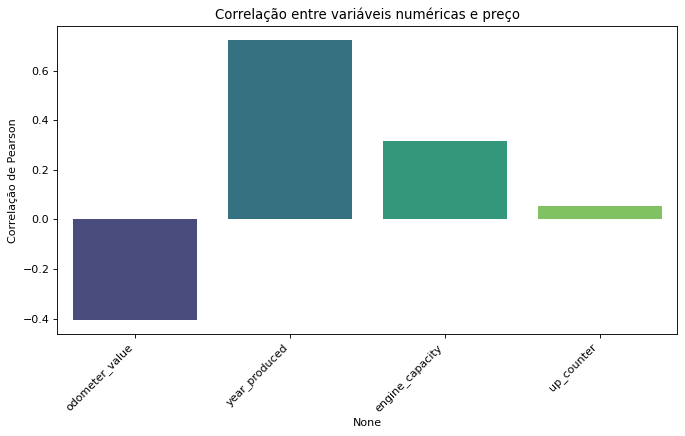

In [ ]:
# Filtrar apenas colunas numéricas do conjunto de treinamento
numeric_features = X_train.select_dtypes(include=["int64", "float64"])


train_corr_df = numeric_features.copy()
train_corr_df["price_usd"] = y_train

# Calcular a correlação de Pearson com o preço
correlations = train_corr_df.corr()["price_usd"].drop("price_usd")

# Plotando a correlação
plt.figure(figsize=(10, 5))
sns.barplot(x=correlations.index, y=correlations.values, hue=correlations.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlação de Pearson")
plt.title("Correlação entre variáveis numéricas e preço")
plt.show()





# aqui observamos a correlação negativa de odometer_value, o que faz sentido pois quanto maior a distância percorrida por um carro, mais ele desvaloriza.




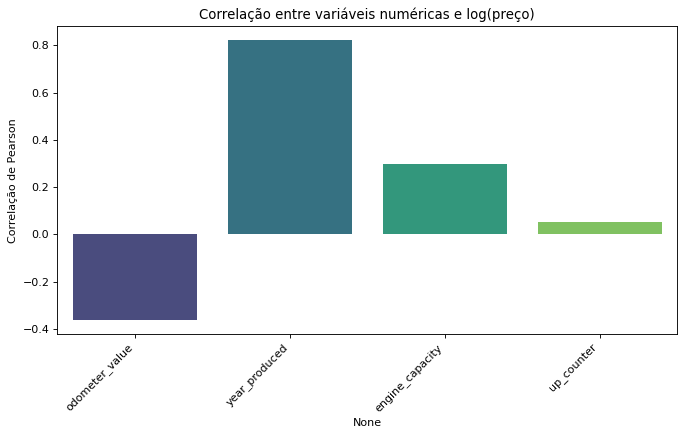

In [ ]:
# Repetindo a análise com o log do preço
train_corr_df["log_price_usd"] = np.log1p(y_train)  # log1p evita log(0)
log_correlations = train_corr_df.corr()["log_price_usd"].drop(["price_usd", "log_price_usd"])

# Plotando a correlação com log(preço)
plt.figure(figsize=(10, 5))
sns.barplot(x=log_correlations.index, y=log_correlations.values, hue=correlations.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlação de Pearson")
plt.title("Correlação entre variáveis numéricas e log(preço)")
plt.show()

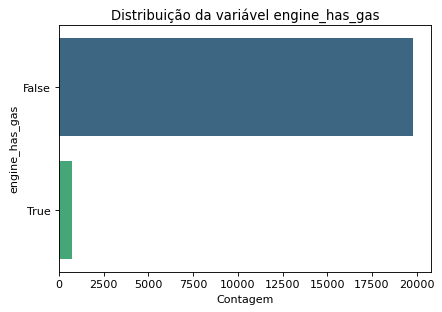

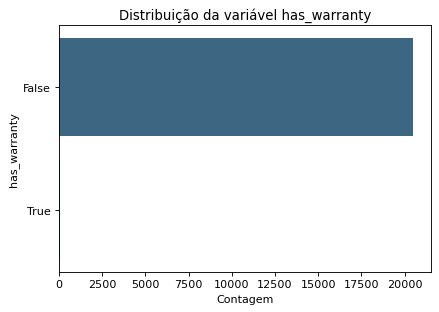

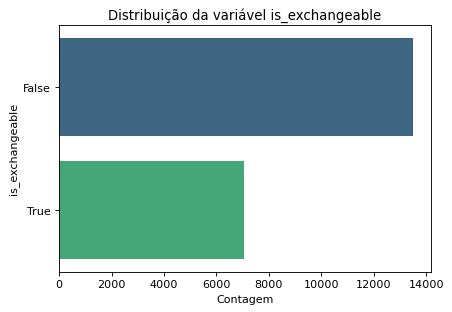

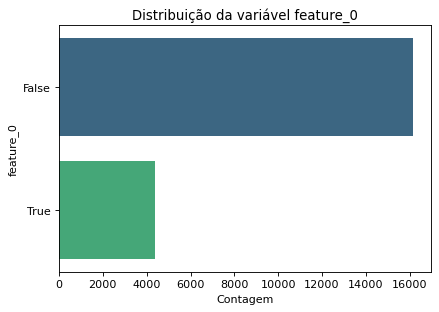

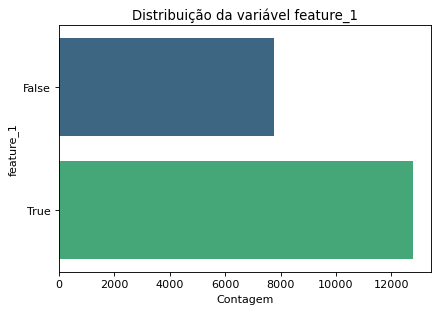

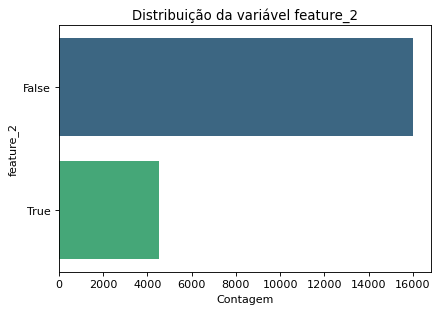

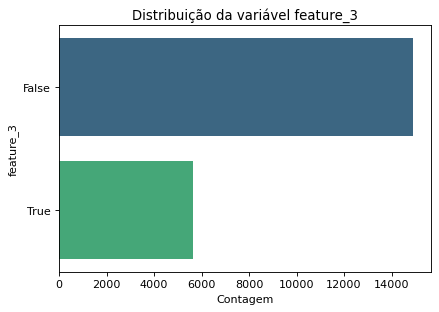

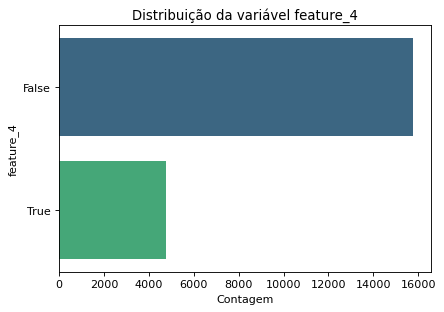

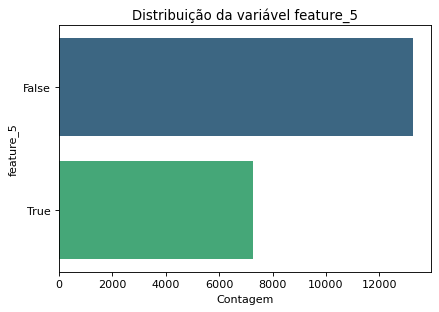

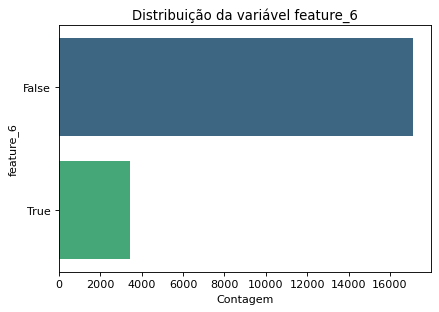

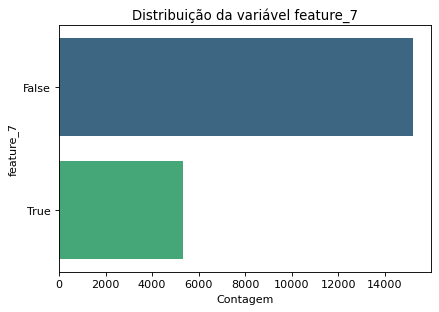

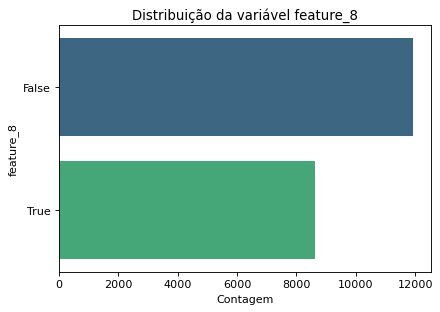

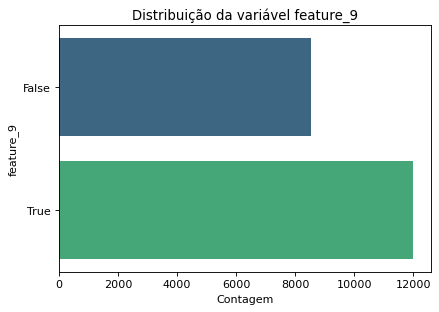

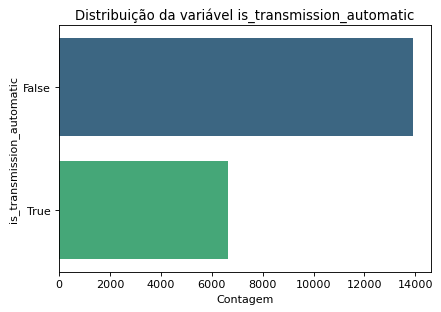

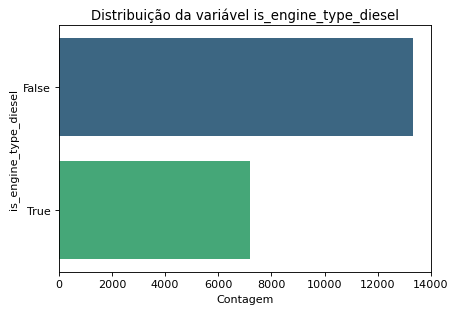

In [ ]:
boolean_vars = X_train.select_dtypes(include="bool").columns


for var in boolean_vars:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=X_train[var], hue=X_train[var], palette="viridis", legend=False)
    plt.title(f"Distribuição da variável {var}")
    plt.xlabel("Contagem")
    plt.ylabel(var)
    plt.show()

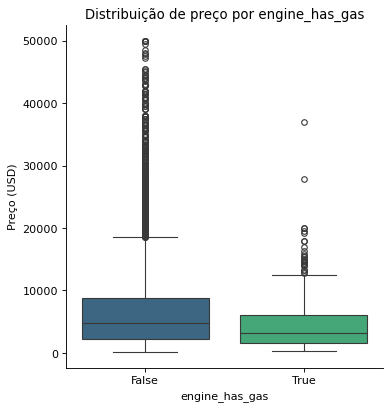

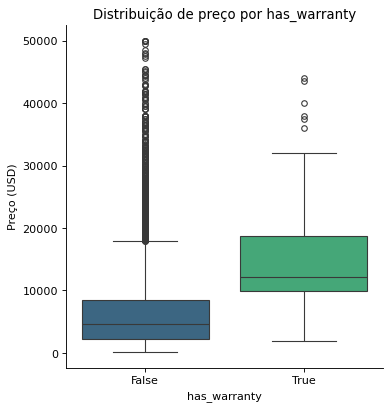

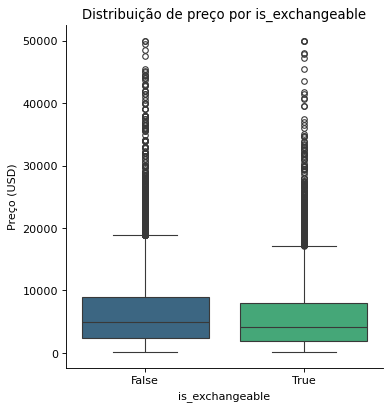

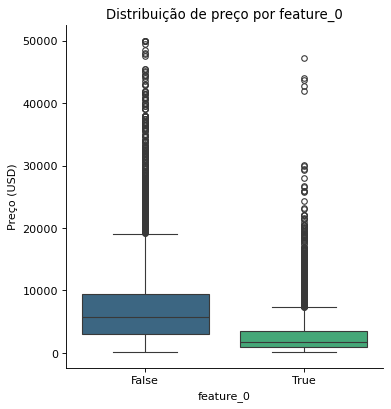

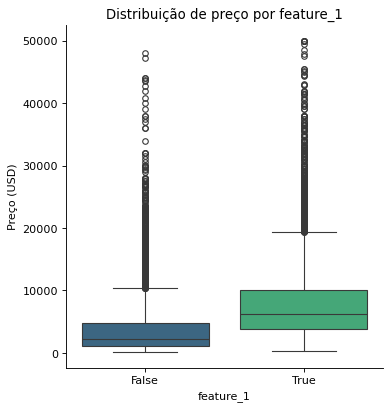

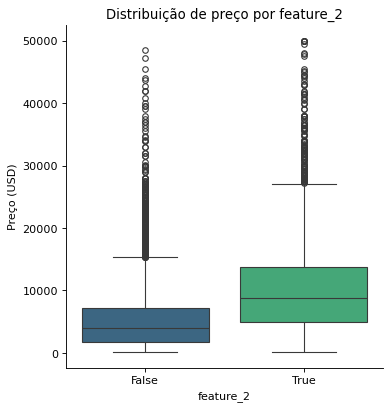

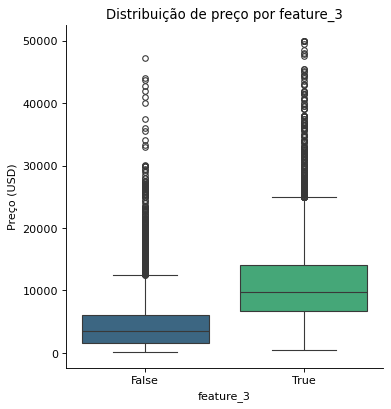

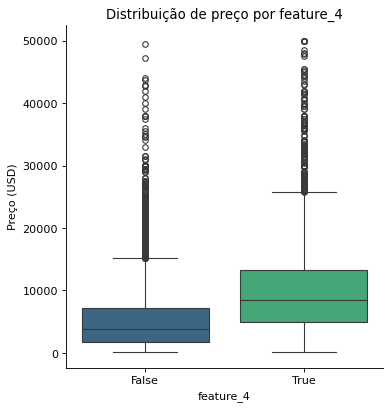

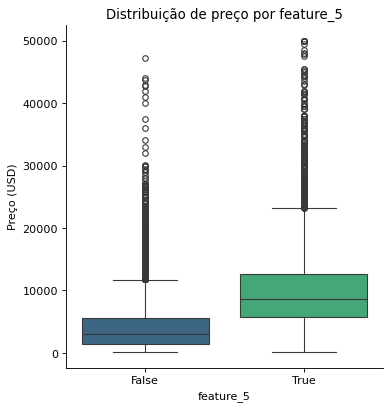

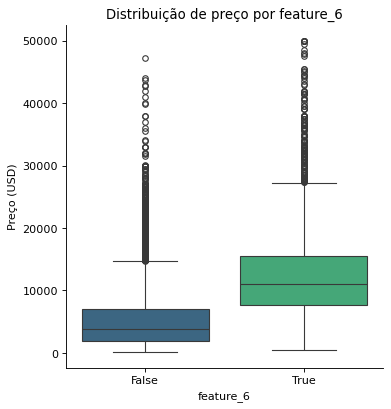

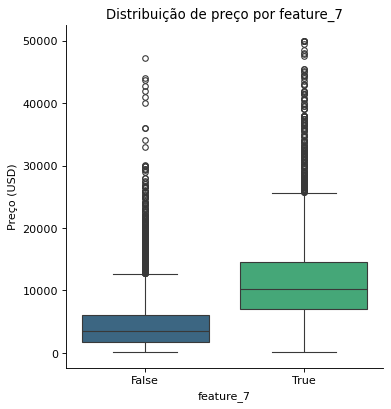

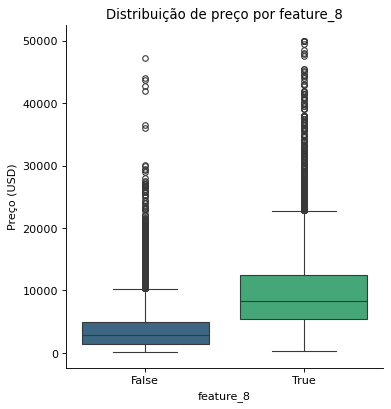

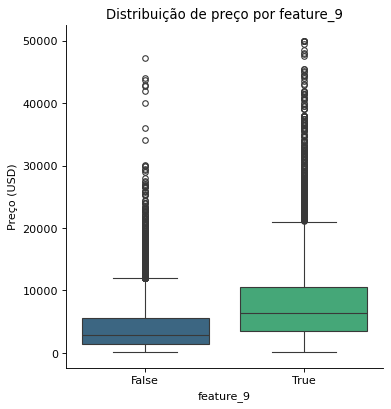

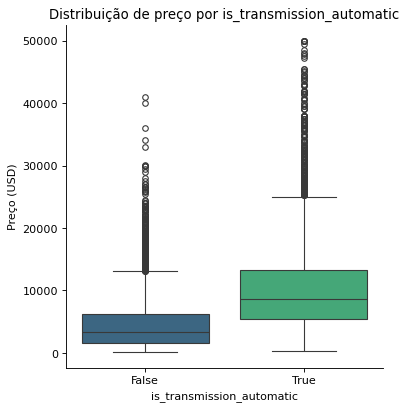

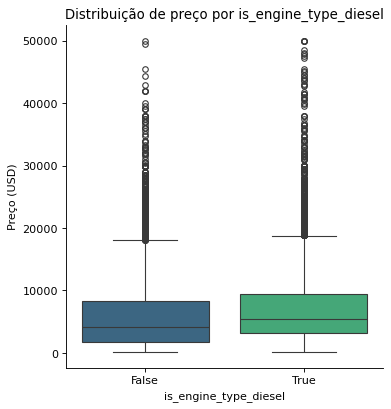

In [ ]:
for var in boolean_vars:
    sns.catplot(x=var, y="price_usd", hue=var, data=X_train.join(y_train), kind="box", palette="viridis", legend=False)

    plt.title(f"Distribuição de preço por {var}")
    plt.xlabel(var)
    plt.ylabel("Preço (USD)")
    plt.show()

# aqui observamos através destes gráficos o cruzamento  das variáveis booleanas com a variável alvo. podemos observar claramento por exemplo,
# no gráfico is_transmission_automatic,
#que quando um carro é automático seu preço tende a ser maior.

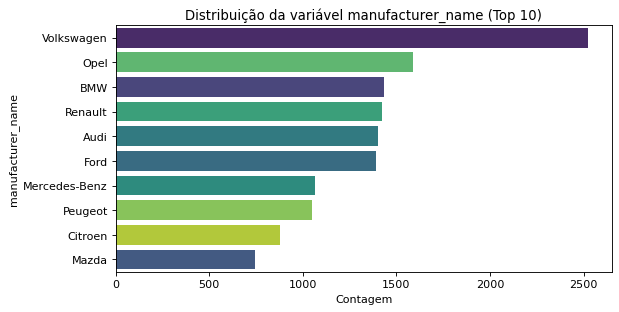

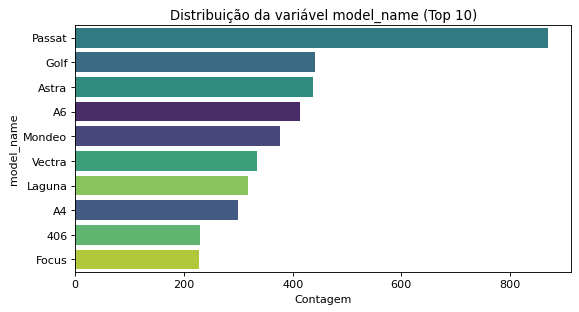

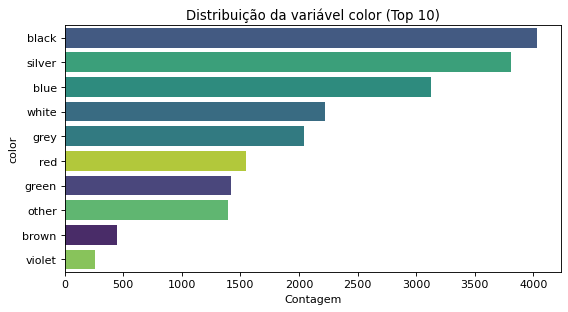

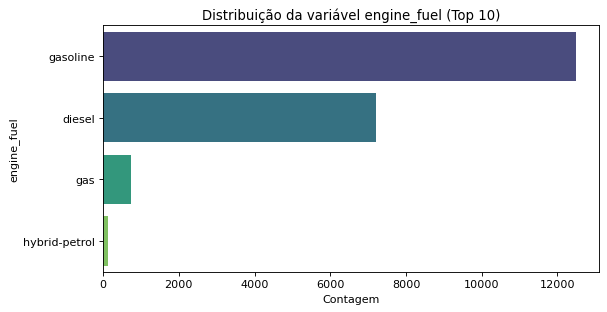

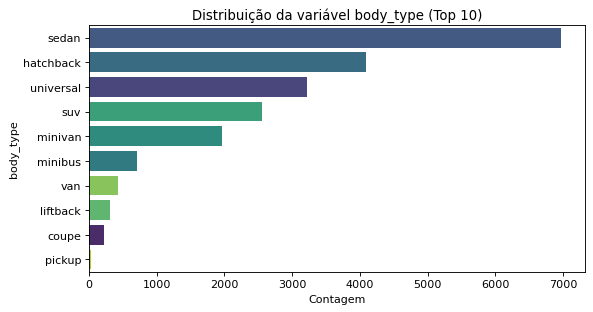

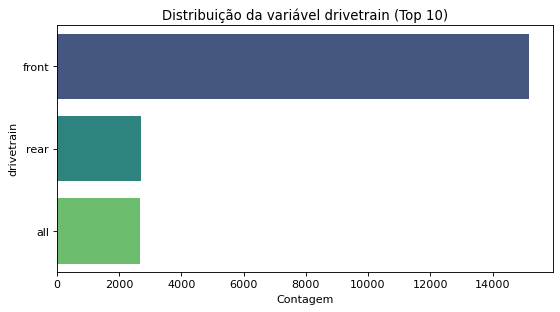

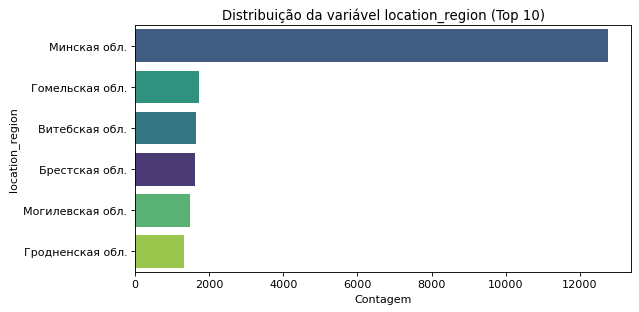

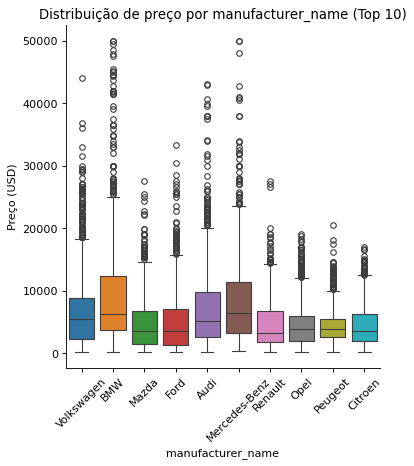

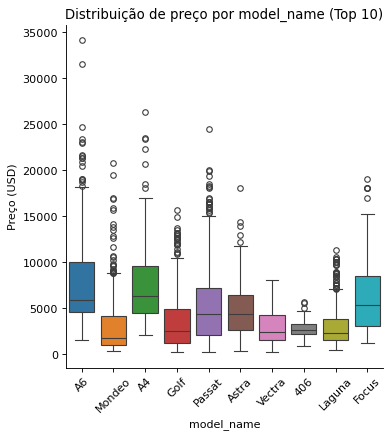

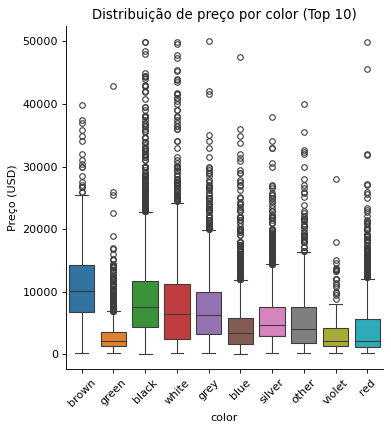

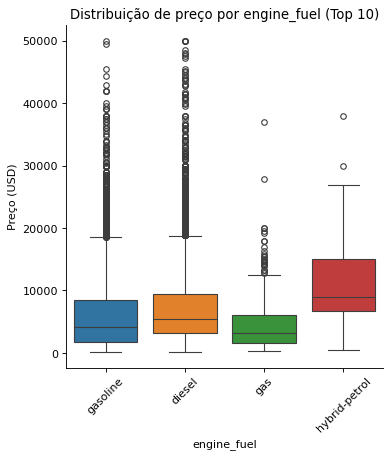

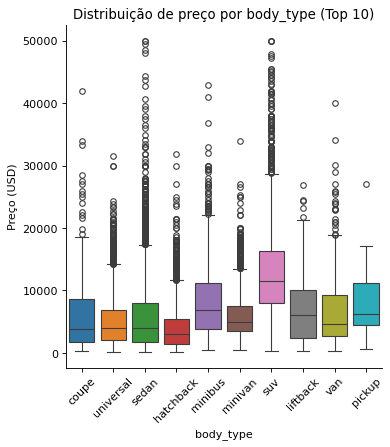

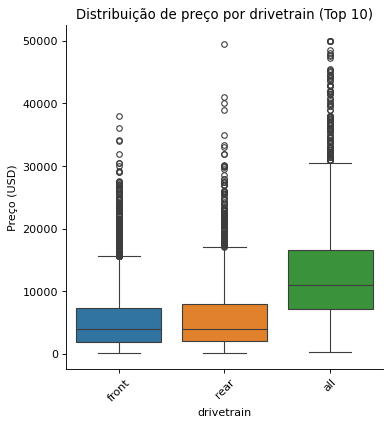

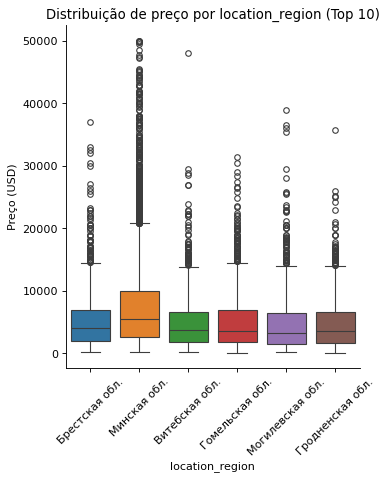

In [ ]:
categorical_vars = X_train.select_dtypes(include="object").columns
top_n = 10  # Número máximo de categorias a serem exibidas

for var in categorical_vars:
    plt.figure(figsize=(8, 4))

    # Seleciona as categorias mais comuns
    top_categories = X_train[var].value_counts().nlargest(top_n).index
    filtered_data = X_train[X_train[var].isin(top_categories)]

    sns.countplot(y=filtered_data[var], hue=filtered_data[var], palette="viridis", order=top_categories, legend=False)


    plt.title(f"Distribuição da variável {var} (Top {top_n})")
    plt.xlabel("Contagem")
    plt.ylabel(var)
    plt.show()

for var in categorical_vars:
    top_categories = X_train[var].value_counts().nlargest(top_n).index
    filtered_data = X_train[X_train[var].isin(top_categories)].join(y_train)

    sns.catplot(x=var, y="price_usd", data=filtered_data, kind="box", hue=var, legend=False)


    plt.xticks(rotation=45)  # Rotaciona rótulos para melhor visualização
    plt.title(f"Distribuição de preço por {var} (Top {top_n})")
    plt.xlabel(var)
    plt.ylabel("Preço (USD)")
    plt.show()


#podemos observar Audi , bmw e mercedes como as marcas com preços mais elevados. Comprovando a eficiência do gráfico.


## discussão
-No primeiro gráfico de correlação observamos que existe uma influência muito grande do ano de produção do carro,
o que é esperado. Já em odometer_value observamos uma correlação negativa, pois quanto mais o carro andou menor seu preço.
-Nos gráficos de variáveis booleanas, observamos que o carro ter garantia eleva consideralvemente seu preço assim como transmissão
automática.
-Carros de marcas como BMW e Mercedes tem um valor maior.
-Carros SUV tender a ser melhor avaliados.
-O interresante desses gráficos é observar que os valores fazem sentido, e também quais features são mais importântes.




# 4- Seleção de hiperparâmetros

## Somente com atributos numéricos


In [ ]:
# Seleciona colunas numéricas
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)
    ]
)

# Pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Treinamento
pipeline.fit(X_train, y_train)

# Previsões
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)

# Avaliação
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

# Resultados
print("(sem escalonamento):")
print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%")


(sem escalonamento):
Treinamento: RMSE = 3461.84, MAPE = 77.10%
Validação : RMSE = 3397.54, MAPE = 77.94%


### Escalonando os dados numéricos

In [ ]:

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)


pipeline_scaled = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('regressor', LinearRegression())
])

# Treinamento
pipeline_scaled.fit(X_train, y_train)

# Previsões
y_train_pred_scaled = pipeline_scaled.predict(X_train)
y_val_pred_scaled = pipeline_scaled.predict(X_val)

# Avaliação
rmse_train_scaled = mean_squared_error(y_train, y_train_pred_scaled, squared=False)
mape_train_scaled = mean_absolute_percentage_error(y_train, y_train_pred_scaled) * 100

rmse_val_scaled = mean_squared_error(y_val, y_val_pred_scaled, squared=False)
mape_val_scaled = mean_absolute_percentage_error(y_val, y_val_pred_scaled) * 100

# Resultados
print("(com StandardScaler):")
print(f"Treinamento: RMSE = {rmse_train_scaled:.2f}, MAPE = {mape_train_scaled:.2f}%")
print(f"Validação : RMSE = {rmse_val_scaled:.2f}, MAPE = {mape_val_scaled:.2f}%")



(com StandardScaler):
Treinamento: RMSE = 3461.84, MAPE = 77.10%
Validação : RMSE = 3397.54, MAPE = 77.94%


### discussão
O escalonamento não foi efetivo pois geralmente o escalonamento tem efeito junto com um modelo com regularização.

## Somente com atributos booleanos

In [ ]:
#4.2
# Seleciona os nomes das colunas booleanas
boolean_features = X_train.select_dtypes(include=bool).columns.tolist()


preprocessor_bool = ColumnTransformer([
    ("bool", "passthrough", boolean_features)
])

# Pipeline com apenas atributos booleanos
pipeline_bool = Pipeline([
    ("preprocessamento", preprocessor_bool),
    ("regressor", LinearRegression())
])

# Treinamento
pipeline_bool.fit(X_train, y_train)

# Previsões
y_train_pred_bool = pipeline_bool.predict(X_train)
y_val_pred_bool = pipeline_bool.predict(X_val)

# Avaliação
rmse_train_bool = mean_squared_error(y_train, y_train_pred_bool, squared=False)
mape_train_bool = mean_absolute_percentage_error(y_train, y_train_pred_bool) * 100

rmse_val_bool = mean_squared_error(y_val, y_val_pred_bool, squared=False)
mape_val_bool = mean_absolute_percentage_error(y_val, y_val_pred_bool) * 100

# Resultados
print(" Usando apenas atributos booleanos:")
print(f"Treinamento: RMSE = {rmse_train_bool:.2f}, MAPE = {mape_train_bool:.2f}%")
print(f"Validação : RMSE = {rmse_val_bool:.2f}, MAPE = {mape_val_bool:.2f}%")


 Usando apenas atributos booleanos:
Treinamento: RMSE = 4074.97, MAPE = 81.08%
Validação : RMSE = 4095.09, MAPE = 82.86%


## Somente com atributos categóricos

In [ ]:
#4.3
# Seleciona colunas categóricas
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Pré-processador para colunas categóricas
preprocessor_cat = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Pipeline com categóricas
pipeline_cat = Pipeline([
    ("preprocessamento", preprocessor_cat),
    ("regressor", LinearRegression())
])

# Treinamento
pipeline_cat.fit(X_train, y_train)

# Previsões
y_train_pred_cat = pipeline_cat.predict(X_train)
y_val_pred_cat = pipeline_cat.predict(X_val)

# Avaliação
rmse_train_cat = mean_squared_error(y_train, y_train_pred_cat, squared=False)
mape_train_cat = mean_absolute_percentage_error(y_train, y_train_pred_cat) * 100

rmse_val_cat = mean_squared_error(y_val, y_val_pred_cat, squared=False)
mape_val_cat = mean_absolute_percentage_error(y_val, y_val_pred_cat) * 100

# Resultados
print(" Usando apenas atributos categóricos (com OneHotEncoder):")
print(f"Treinamento: RMSE = {rmse_train_cat:.2f}, MAPE = {mape_train_cat:.2f}%")
print(f"Validação : RMSE = {rmse_val_cat:.2f}, MAPE = {mape_val_cat:.2f}%")

 Usando apenas atributos categóricos (com OneHotEncoder):
Treinamento: RMSE = 3694.76, MAPE = 73.56%
Validação : RMSE = 3722.92, MAPE = 74.98%


## Todos os atributos

In [ ]:
#ITEM 4.4 , TODODS OS ATRIBUTOS
# 1. Identifica colunas por tipo
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
boolean_features = X_train.select_dtypes(include='bool').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()


preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("bool", "passthrough", boolean_features),
    ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# 3. Pipeline
pipeline_all = Pipeline(steps=[
    ("preprocessamento", preprocessor),
    ("regressor", LinearRegression())
])

# 4. Treinamento
pipeline_all.fit(X_train, y_train)

# 5. Previsões
y_train_pred = pipeline_all.predict(X_train)
y_val_pred = pipeline_all.predict(X_val)

# 6. Avaliação
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

# 7. Resultados
print(" Resultados com todos os atributos:")
print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%")


 Resultados com todos os atributos:
Treinamento: RMSE = 2370.78, MAPE = 50.06%
Validação : RMSE = 2378.38, MAPE = 50.62%


## Polynomial features

In [ ]:
#item 4.5
# Seleciona apenas os dados numéricos
X_train_num = X_train.select_dtypes(include=np.number)
X_val_num = X_val.select_dtypes(include=np.number)

# Testar diferentes graus
for d in [1,2, 3, 4, 5, 6, 7,8,9, 10]:
    print(f"\n Degree = {d}")

    # Pipeline com Polynomial + Escalonamento + Regressão
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])

    # Treina o modelo
    poly_pipeline.fit(X_train_num, y_train)

    # Previsões
    y_train_pred = poly_pipeline.predict(X_train_num)
    y_val_pred = poly_pipeline.predict(X_val_num)

    # Avaliação
    rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

    rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
    mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

    print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
    print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%")


 Degree = 1
Treinamento: RMSE = 3461.84, MAPE = 77.10%
Validação : RMSE = 3397.54, MAPE = 77.94%

 Degree = 2
Treinamento: RMSE = 2700.53, MAPE = 45.27%
Validação : RMSE = 2610.45, MAPE = 45.27%

 Degree = 3
Treinamento: RMSE = 2485.87, MAPE = 40.81%
Validação : RMSE = 2470.29, MAPE = 41.76%

 Degree = 4
Treinamento: RMSE = 2431.34, MAPE = 39.02%
Validação : RMSE = 2826.13, MAPE = 39.70%

 Degree = 5
Treinamento: RMSE = 2405.40, MAPE = 38.96%
Validação : RMSE = 3099.13, MAPE = 44.43%

 Degree = 6
Treinamento: RMSE = 2383.61, MAPE = 38.74%
Validação : RMSE = 17359.34, MAPE = 57.70%

 Degree = 7
Treinamento: RMSE = 2363.29, MAPE = 38.33%
Validação : RMSE = 530704.81, MAPE = 366.29%

 Degree = 8
Treinamento: RMSE = 2335.67, MAPE = 38.18%
Validação : RMSE = 924005.67, MAPE = 690.78%

 Degree = 9
Treinamento: RMSE = 2306.44, MAPE = 38.06%
Validação : RMSE = 2505888.42, MAPE = 2209.40%

 Degree = 10
Treinamento: RMSE = 2255.62, MAPE = 37.53%
Validação : RMSE = 829019384.90, MAPE = 506194.97

### DISCUSSÃO
Foi observado que colocar um grau muito elevado como 6 ou mais, faz com que o modelo se ajuste
muito mais que o necessário aos dados de treino, e aos generalizar e ser testado em
outros dados não é eficiente.
- 4 é um valor bom tanto no treino quanto na validação.

## Ridge

In [ ]:
### Separando colunas por tipo
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()


def avaliar_ridge_poly(degree, alpha):
    # Pré-processamento: somente atributos numéricos com PolynomialFeatures
    preprocessor = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler())
    ])

    # Pipeline com Ridge
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    # Treinamento
    pipeline.fit(X_train[num_cols], y_train)

    # Previsões
    y_train_pred = pipeline.predict(X_train[num_cols])
    y_val_pred = pipeline.predict(X_val[num_cols])

    # Avaliação
    rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

    rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
    mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

    print(f"Degree = {degree}, Alpha = {alpha}")
    print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
    print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%\n")

# Testes
for degree in [2,4,5,8, 10]:
    for alpha in [0.001, 0.01, 0.05, 0.1,0.5 , 1 , 5,10, 30]:
        avaliar_ridge_poly(degree, alpha)


Degree = 2, Alpha = 0.001
Treinamento: RMSE = 2700.68, MAPE = 45.13%
Validação : RMSE = 2609.44, MAPE = 45.06%

Degree = 2, Alpha = 0.01
Treinamento: RMSE = 2712.23, MAPE = 44.65%
Validação : RMSE = 2614.47, MAPE = 44.14%

Degree = 2, Alpha = 0.05
Treinamento: RMSE = 2819.53, MAPE = 50.47%
Validação : RMSE = 2722.83, MAPE = 50.15%

Degree = 2, Alpha = 0.1
Treinamento: RMSE = 2926.18, MAPE = 57.22%
Validação : RMSE = 2838.26, MAPE = 56.85%

Degree = 2, Alpha = 0.5
Treinamento: RMSE = 3168.21, MAPE = 70.76%
Validação : RMSE = 3100.21, MAPE = 70.00%

Degree = 2, Alpha = 1
Treinamento: RMSE = 3225.85, MAPE = 73.73%
Validação : RMSE = 3161.85, MAPE = 72.85%

Degree = 2, Alpha = 5
Treinamento: RMSE = 3280.84, MAPE = 76.46%
Validação : RMSE = 3220.23, MAPE = 75.46%

Degree = 2, Alpha = 10
Treinamento: RMSE = 3288.41, MAPE = 76.77%
Validação : RMSE = 3228.12, MAPE = 75.76%

Degree = 2, Alpha = 30
Treinamento: RMSE = 3293.81, MAPE = 76.80%
Validação : RMSE = 3233.35, MAPE = 75.76%

Degree = 4, 

### discussão
Aqui podemos mostrar que a regularização execiva não é eficiente
vamos ficar com grau 4 e alpha 0.01

## TTR

In [ ]:
#item 4.6
# Separar os tipos de colunas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# Pré-processamento
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("bool", "passthrough", bool_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
])


model = LinearRegression()


ttr_model = TransformedTargetRegressor(
    regressor=model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Pipeline completa
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ttr_model)
])

# Treinamento
pipeline.fit(X_train, y_train)

# Previsões
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)

# Avaliação
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

print(" Resultados com TransformedTargetRegressor (log):")
print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%")

 Resultados com TransformedTargetRegressor (log):
Treinamento: RMSE = 1669.54, MAPE = 22.20%
Validação : RMSE = 1719.89, MAPE = 22.59%


## TTR+Poly(+Ridge)

In [ ]:
#item 4.7
# Separar os tipos de colunas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# Pré-processamento
preprocessor = ColumnTransformer([
    ("poly_num", Pipeline([
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("bool", "passthrough", bool_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
])


ridge_model = Ridge(alpha=0.01)


ttr_model = TransformedTargetRegressor(
    regressor=ridge_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Pipeline completa
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ttr_model)
])

# Treinamento
pipeline.fit(X_train, y_train)

# Previsões
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)


# Avaliação
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100

rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100


print(" Resultados com Polynomial(degree=4) + Ridge(alpha=0.01) + TTR (log1p):")
print(f"Treinamento: RMSE = {rmse_train:.2f}, MAPE = {mape_train:.2f}%")
print(f"Validação : RMSE = {rmse_val:.2f}, MAPE = {mape_val:.2f}%")



 Resultados com Polynomial(degree=4) + Ridge(alpha=0.01) + TTR (log1p):
Treinamento: RMSE = 1695.00, MAPE = 22.20%
Validação : RMSE = 1733.34, MAPE = 22.87%


### Discussão
-Nestes itens como foi realizado o treinamento e avaliação para diversos festures separadamente, foi possivel observar
a importancia de cada uma.
- Inicialmente observamos que as colunas numéricas, booleanas e categóricas usadas de forma separada sem qualquer tipo de tratamento
 dos dados são pouco eficiêntes.
- O TransformTargetRegressor foi de grande importância, devido a termos variações grandes nos preços dos carros.

# 5- Retreinamento e resultados no conjunto de teste

In [ ]:
# Previsões no conjunto de teste
y_test_pred = pipeline.predict(X_test)

# Avaliação no conjunto de teste
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print("\n Resultados no Conjunto de Teste:")
print(f"Teste: RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}%")




 Resultados no Conjunto de Teste:
Teste: RMSE = 1682.62, MAPE = 22.93%


## discussão
Aqui observamos que obtemos um MAPE semelhante no conjunto de teste e no conjunto de validação,
o que indica que o modelo não se ajustou demais ao conjunto de validação, mas sim conseguiu generalizar
para outro conjunto.

# 6- Atividades
Aqui juntaremos os dados de teste e validação


## Regressão linear com todos os atributos

In [ ]:
# Junta os dados de treino e validação
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Separa os tipos de colunas
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train_val.select_dtypes(include='bool').columns.tolist()
cat_cols = X_train_val.select_dtypes(include='object').columns.tolist()

# Pré-processador
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("bool", "passthrough", bool_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
])

# Modelo: Regressão Linear
model = LinearRegression()

# Pipeline completa
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", model)
])

# Treinamento com treino + validação
pipeline.fit(X_train_val, y_train_val)

# Previsões
y_train_val_pred = pipeline.predict(X_train_val)
y_test_pred = pipeline.predict(X_test)

# Avaliação
rmse_train_val = mean_squared_error(y_train_val, y_train_val_pred, squared=False)
mape_train_val = mean_absolute_percentage_error(y_train_val, y_train_val_pred) * 100

rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# Resultados
print(" Resultados - Regressão Linear (todos os atributos):")
print(f"Treino+Validação: RMSE = {rmse_train_val:.2f}, MAPE = {mape_train_val:.2f}%")
print(f"Teste           : RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}%")


 Resultados - Regressão Linear (todos os atributos):
Treino+Validação: RMSE = 2362.85, MAPE = 49.91%
Teste           : RMSE = 2479.24, MAPE = 52.83%


## Polynomial features

In [ ]:
# Seleciona apenas colunas numéricas
X_train_val_num = X_train_val.select_dtypes(include=np.number)
X_test_num = X_test.select_dtypes(include=np.number)

# Pipeline com Polynomial Features (grau 4) + Escalonamento + Regressão Linear
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

# Treinamento
poly_pipeline.fit(X_train_val_num, y_train_val)

# Previsões
y_train_val_pred = poly_pipeline.predict(X_train_val_num)
y_test_pred = poly_pipeline.predict(X_test_num)

# Avaliação
rmse_train_val = mean_squared_error(y_train_val, y_train_val_pred, squared=False)
mape_train_val = mean_absolute_percentage_error(y_train_val, y_train_val_pred) * 100

rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# Resultados
print(" Resultados com PolynomialFeatures (grau 4) + Regressão Linear:")
print(f"Treinamento/Validação: RMSE = {rmse_train_val:.2f}, MAPE = {mape_train_val:.2f}%")
print(f"Teste              : RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}%")

 Resultados com PolynomialFeatures (grau 4) + Regressão Linear:
Treinamento/Validação: RMSE = 2427.83, MAPE = 38.84%
Teste              : RMSE = 2465.26, MAPE = 38.51%


## TTR


In [ ]:

# Separar os tipos de colunas
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train_val.select_dtypes(include='bool').columns.tolist()
cat_cols = X_train_val.select_dtypes(include='object').columns.tolist()

# Pré-processamento
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("bool", "passthrough", bool_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
])

# Modelo base
model = LinearRegression()

# TTR com log1p no target
ttr_model = TransformedTargetRegressor(
    regressor=model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Pipeline completa
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ttr_model)
])

# Treinamento
pipeline.fit(X_train_val, y_train_val)

# Previsões
y_train_val_pred = pipeline.predict(X_train_val)
y_test_pred = pipeline.predict(X_test)

# Avaliação
rmse_train_val = mean_squared_error(y_train_val, y_train_val_pred, squared=False)
mape_train_val = mean_absolute_percentage_error(y_train_val, y_train_val_pred) * 100

rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# Resultados
print(" Resultados com TransformedTargetRegressor (log1p) + Regressão Linear:")
print(f"Treinamento/Validação: RMSE = {rmse_train_val:.2f}, MAPE = {mape_train_val:.2f}%")
print(f"Teste              : RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}%")


 Resultados com TransformedTargetRegressor (log1p) + Regressão Linear:
Treinamento/Validação: RMSE = 1669.31, MAPE = 22.23%
Teste              : RMSE = 1672.91, MAPE = 23.00%


## TTR+Poly(+Ridge)


In [ ]:
# Separar tipos de colunas
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
bool_cols = X_train_val.select_dtypes(include='bool').columns.tolist()
cat_cols = X_train_val.select_dtypes(include='object').columns.tolist()

# Pré-processamento com PolynomialFeatures + scaler para colunas numéricas
preprocessor = ColumnTransformer([
    ("poly_num", Pipeline([
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("bool", "passthrough", bool_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
])


ridge_model = Ridge(alpha=0.01)


ttr_model = TransformedTargetRegressor(
    regressor=ridge_model,
    func=np.log1p,
    inverse_func=np.expm1
)


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ttr_model)
])

# Treinar com dados concatenados (treinamento + validação)
pipeline.fit(X_train_val, y_train_val)

# Avaliação nos dados de treino/validação e teste
y_trainval_pred = pipeline.predict(X_train_val)
y_test_pred = pipeline.predict(X_test)

# Métricas
rmse_trainval = mean_squared_error(y_train_val, y_trainval_pred, squared=False)
mape_trainval = mean_absolute_percentage_error(y_train_val, y_trainval_pred) * 100

rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

# Resultados
print(" Resultados TTR + Poly(degree=4) + Ridge(alpha=0.01):")
print(f"Treino/Validação: RMSE = {rmse_trainval:.2f}, MAPE = {mape_trainval:.2f}%")
print(f"Teste           : RMSE = {rmse_test:.2f}, MAPE = {mape_test:.2f}%")


 Resultados TTR + Poly(degree=4) + Ridge(alpha=0.01):
Treino/Validação: RMSE = 1680.36, MAPE = 22.24%
Teste           : RMSE = 1658.52, MAPE = 22.91%


# 7- Análise de resultados

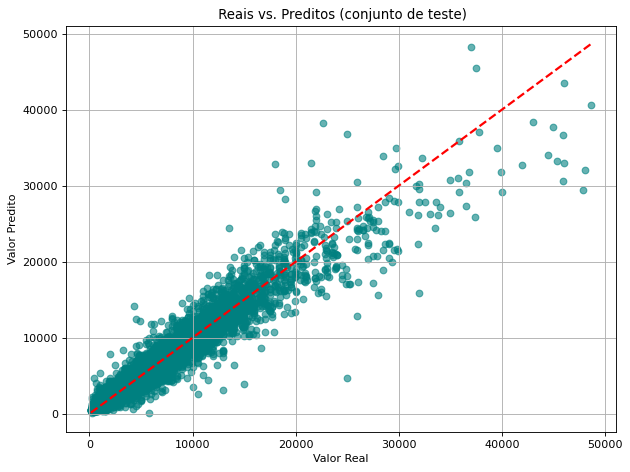

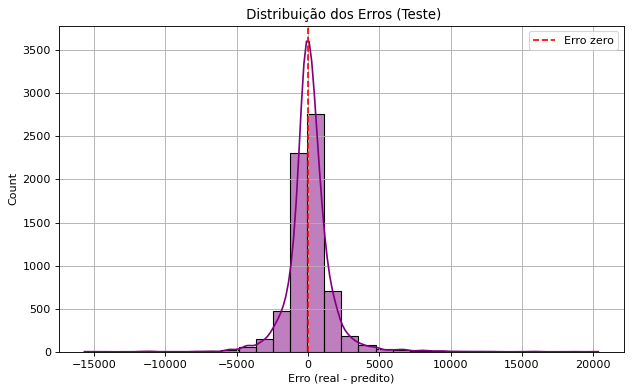

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title(" Reais vs. Preditos (conjunto de teste)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# DISTRIBUIÇÃO DOS ERROS
# -------------------------
errors = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, color='purple', bins=30)
plt.axvline(0, color='red', linestyle='--', label='Erro zero')
plt.xlabel("Erro (real - predito)")
plt.title(" Distribuição dos Erros (Teste)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Se a metrica de avaliação fosse RMSE não mudaria muito o produto final, pois as duas métricas se diziam equivalente na maioria dos
#casos, a não ser por pequenas decisões como escolher um polinomio de grau 3 ao invez de 4 por exemplo, que na metrica RMSE
#era levemente melhor que se fosse analisar pelo MAPE

# 8- Conclusões

Neste trabalho foi muito interressante aprender o passo a passo completo do treinamento de um modelo desde o inicio com a limpagem dos dados, até a seleção de hiperparâmetros e verificação do desempenho final do modelo. Ficou bem claro a influência dos hiperparâmetros.

Analisando o resultado final no conjunto de teste de um MAPE de 22.91%, no meu ver é um bom resultado tendo em vista que os valores são colocados no site por pessoas, que podem cometer erros de digitação ou até mesmo colocar um valor maior ou menor do que o carro realmente vale.

Esse erro de 22.91% também é importante lembrar que quanto maior for o valor de carro mais impacto terá, mas levando em conta que
neste dataset os preços dos carros variam desde valores baixos até carros caros, teria como se ter uma boa predição de valores.

Também foi interressante entender o que é importante analisar em um DataFrame na questão de limpeza dos dados, como dados faltantes, duplicados, outliers, features desnecessárias e etc.